In [8]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([
    [0, 0, 0],
    [1, 2, 3],
    [3, 3, 3],
    [2, -1, 4]
])

p1, p2, p3, p4 = points[0], points[1], points[2], points[3]

print('евклидово расстояние')
print(np.linalg.norm(p1 - p2))

print('квадрат евклидова расстояния')
print(np.linalg.norm(p1 - p2) ** 2)

print('расстояние чебышева')
print(np.linalg.norm(p1 - p2, ord=np.inf))

print('расстояние хемминга')
print(np.linalg.norm(p1 - p2, ord=1))

евклидово расстояние
3.7416573867739413
квадрат евклидова расстояния
14.0
расстояние чебышева
3.0
расстояние хемминга
6.0


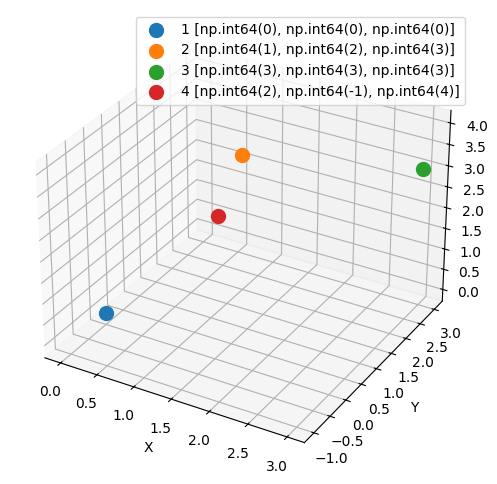

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for i, p in enumerate(points):
    ax.scatter(p[0], p[1], p[2], s=100, label=f'{i+1} {list(p)}')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

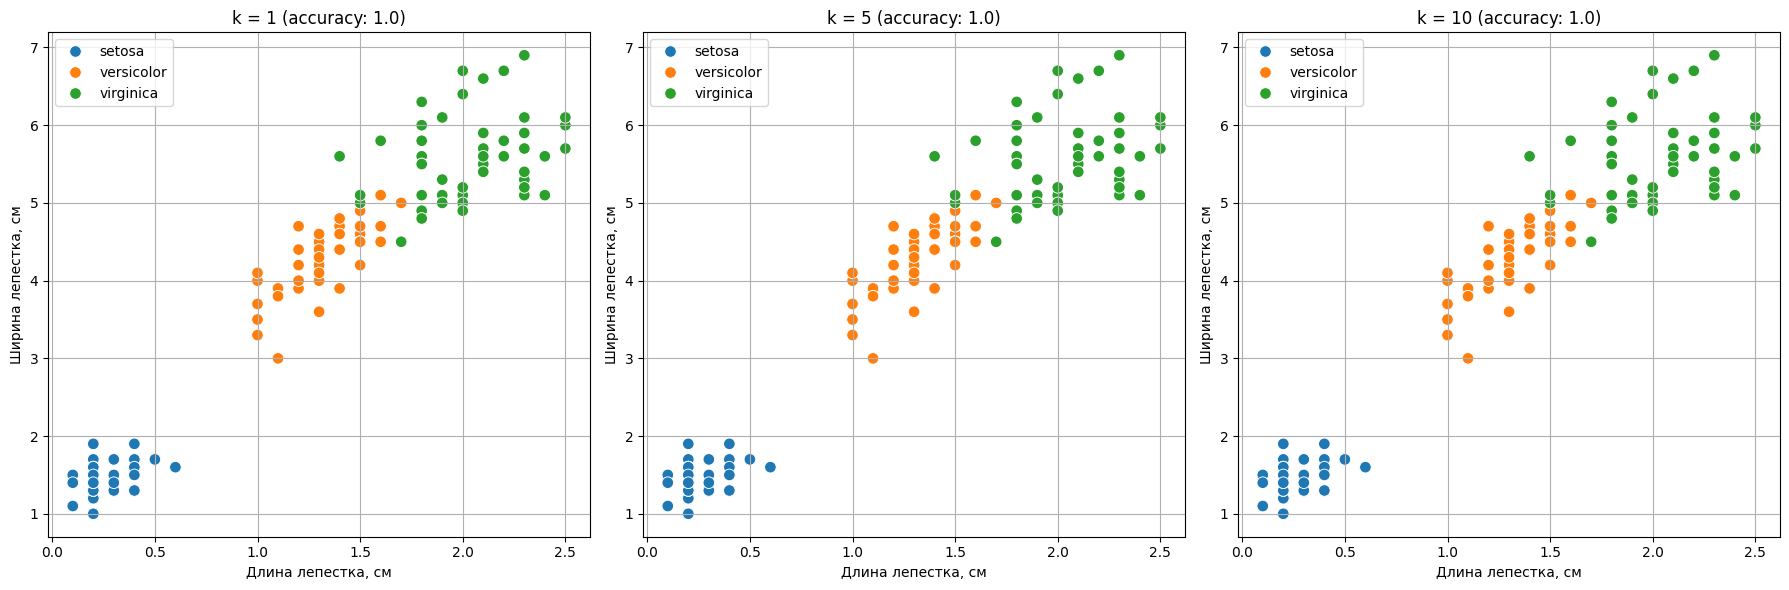

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = sns.load_dataset('iris')

X_train, X_test, y_train, y_test = train_test_split(
    iris.iloc[:, :-1],
    iris.iloc[:, -1],
    test_size=0.15,
    random_state=42
)

k_values = [1, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, k in enumerate(k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f'accuracy при k = {k}: {acc}')

    ax = axes[idx]
    sns.scatterplot(x='petal_width', y='petal_length', data=iris, hue='species', s=70, ax=ax)
    ax.set_title(f'k = {k} (accuracy: {acc})')
    ax.set_xlabel('Длина лепестка, см')
    ax.set_ylabel('Ширина лепестка, см')
    ax.grid(True)

    y_test_arr = np.array(y_test)

    for i in range(len(y_test_arr)):
        if y_test_arr[i] != y_pred[i]:
            test_idx = y_test.index[i]
            ax.scatter(
                X_test.loc[test_idx, 'petal_width'],
                X_test.loc[test_idx, 'petal_length'],
                color='red', s=150, marker='X'
            )
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
from sklearn.feature_extraction import DictVectorizer

data_dict = [
    {'цвет_глаз': 'карий', 'телосложение': 'стройное'},
    {'цвет_глаз': 'голубой', 'телосложение': 'полное'},
    {'цвет_глаз': 'зеленый', 'телосложение': 'стройное'},
    {'цвет_глаз': 'голубой', 'телосложение': 'среднее'},
    {'цвет_глаз': 'карий', 'телосложение': 'среднее'}
]
dictvectorizer = DictVectorizer(sparse=False)
features = dictvectorizer.fit_transform(data_dict)
print(features)
print(dictvectorizer.get_feature_names_out())

[[0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 1.]]
['телосложение=полное' 'телосложение=среднее' 'телосложение=стройное'
 'цвет_глаз=голубой' 'цвет_глаз=зеленый' 'цвет_глаз=карий']
